# 7. Fine-tuning to follow instructions

In [17]:
import json
from functools import partial
from dataclasses import asdict

import tiktoken
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from gpt.tokenize import text_to_token_ids, token_ids_to_text
from gpt.model import GPTModel, GPTConfig
from gpt.weights import download_and_load_gpt2, load_weights_into_gpt
from gpt.pretrain import generate, calc_loss_loader, train_model_simple, plot_losses

## 7.2 Preparing a dataset for supervised instruction finte-tuning

In [2]:
instruction_examples_file_path = "instruction-data.json"

with open(instruction_examples_file_path, "r") as file:
    instruction_examples = json.load(file)

print("Number of entries:", len(instruction_examples))
instruction_examples[50]

Number of entries: 1100


{'instruction': 'Identify the correct spelling of the following word.',
 'input': 'Ocassion',
 'output': "The correct spelling is 'Occasion.'"}

In [3]:
def format_example(instruction, input, output):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a reponse that appropriately completes the request."
        f"\n\n### Instruction:\n{instruction}"
    )
    if input:
        input_text = f"\n\n### Input:\n{input}"
    else:
        input_text = ""

    output = f"\n\n### Response:\n{output}"

    return instruction_text + input_text + output


example_text = format_example(**instruction_examples[50])
print(example_text)

Below is an instruction that describes a task. Write a reponse that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [4]:
example_text = format_example(**instruction_examples[999])
print(example_text)

Below is an instruction that describes a task. Write a reponse that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [5]:
train_portion = int(len(instruction_examples) * 0.85)    
test_portion = int(len(instruction_examples) * 0.1)            
validation_portion = len(instruction_examples) - train_portion - test_portion    

train_data = instruction_examples[:train_portion]
test_data = instruction_examples[train_portion:train_portion + test_portion]
validation_data = instruction_examples[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(validation_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 Organizing data into training batches

In [6]:
class InstructionDataset(Dataset):

    def __init__(self, examples: dict, tokenizer):
        self.examples = examples
        self.example_text_token_ids = []
        for example in examples:
            example_text = format_example(**example)
            self.example_text_token_ids.append(tokenizer.encode(example_text))

    def __getitem__(self, idx):
        return self.example_text_token_ids[idx]

    def __len__(self):
        return len(self.examples)

In [7]:
def custom_collate_draft_1(batch, pad_token_id=50256, device='mps'):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_list = []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item 
            + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_list.append(inputs)
    
    inputs_tensor = torch.stack(inputs_list).to(device)
    return inputs_tensor

inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = [inputs_1, inputs_2, inputs_3]
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='mps:0')


In [8]:
def custom_collate_draft_2(
    batch, pad_token_id=50256, device='mps'
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_list, targets_list = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item 
            + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        target = torch.tensor(padded[1:])
        inputs_list.append(inputs)
        targets_list.append(target)
    
    inputs_tensor = torch.stack(inputs_list).to(device)
    target_tensor = torch.stack(targets_list).to(device)
    return inputs_tensor, target_tensor

print(*custom_collate_draft_2(batch), sep="\n\n")

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='mps:0')

tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]], device='mps:0')


In [9]:
def custom_collate_fn(
    batch, 
    pad_token_id=50256, 
    ignore_index=-100,
    allowed_max_length=None,  
    device='mps'
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_list, targets_list = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item 
            + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        mask_indices = torch.nonzero(mask).squeeze()
        if mask_indices.numel() > 1:
            targets[mask_indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_list.append(inputs)
        targets_list.append(targets)
    
    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)
    return inputs_tensor, targets_tensor

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='mps:0')
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]], device='mps:0')


## 7.4 Creating data loaders for an instruction dataset

In [10]:
customized_collate_fn = partial(
    custom_collate_fn, 
    allowed_max_length=1024, 
    device='mps'
)

In [11]:
tokenizer = tiktoken.get_encoding("gpt2")
tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
)

validation_dataset = InstructionDataset(validation_data, tokenizer)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

In [12]:
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 84]) torch.Size([8, 84])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 69]) torch.Size([8, 69])


## 7.5 Loading a pre-trained LLm

In [13]:
BASE_CONFIG = {
    "vocabulary_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "dropout_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "124M": {"embedding_dim": 768, "num_transformers": 12, "num_heads": 12},
    "355M": {"embedding_dim": 1024, "num_transformers": 24, "num_heads": 16},
    "774M": {"embedding_dim": 1280, "num_transformers": 36, "num_heads": 20},
    "1558M": {"embedding_dim": 1600, "num_transformers": 48, "num_heads": 25},
}

model_size = "124M"

settings, params = download_and_load_gpt2(
    model_size=model_size, 
    models_dir="gpt2"
)
gpt_config = GPTConfig(**BASE_CONFIG, **model_configs[model_size])
model = GPTModel(**asdict(gpt_config))
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (token_embedding_layer): Embedding(50257, 768)
  (position_embedding_layer): Embedding(1024, 768)
  (embedding_dropout_layer): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm()
      (feed_forward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlo

In [14]:
torch.manual_seed(123)
input_text = format_example(**validation_data[0])
print(input_text)

Below is an instruction that describes a task. Write a reponse that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:
The meal is cooked by the chef every day.


In [15]:
token_ids = generate(
    model=model,
    token_ids=text_to_token_ids(input_text, tokenizer),
    num_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Response:

The chef cooks the meal every day.

### Response:


## 7.6 Fine-tuning the LLM on instruction data

In [16]:
device = 'mps'

model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        validation_loader, model, device, num_batches=5
    )

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 4.174203109741211
Validation loss: 4.0584064483642575


In [24]:
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, validation_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_num_batches=5,
    start_tokens=format_example(**validation_data[0]), 
    tokenizer=tokenizer
)

Ep 1 (Step  00000): Train loss 4.213, Validation loss 4.117
Ep 1 (Step  00005): Train loss 4.316, Validation loss 4.188
Ep 1 (Step  00010): Train loss 4.127, Validation loss 4.179
Ep 1 (Step  00015): Train loss 4.303, Validation loss 4.287
Ep 1 (Step  00020): Train loss 4.288, Validation loss 4.294
Ep 1 (Step  00025): Train loss 4.250, Validation loss 4.308
Ep 1 (Step  00030): Train loss 4.391, Validation loss 4.291
Ep 1 (Step  00035): Train loss 4.251, Validation loss 4.240
Ep 1 (Step  00040): Train loss 4.144, Validation loss 4.062
Ep 1 (Step  00045): Train loss 3.954, Validation loss 3.929
Ep 1 (Step  00050): Train loss 3.885, Validation loss 3.851
Ep 1 (Step  00055): Train loss 4.064, Validation loss 3.923
Ep 1 (Step  00060): Train loss 4.136, Validation loss 4.061
Ep 1 (Step  00065): Train loss 4.140, Validation loss 4.089
Ep 1 (Step  00070): Train loss 4.066, Validation loss 4.027
Ep 1 (Step  00075): Train loss 3.946, Validation loss 3.923
Ep 1 (Step  00080): Train loss 3.869, Va

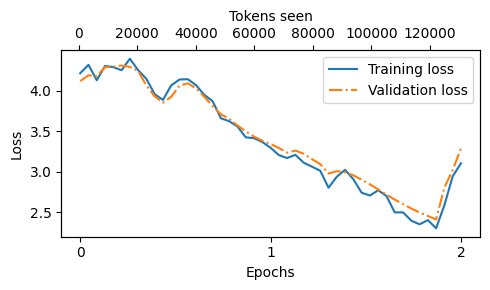

In [25]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [ ]:
torch.manual_seed(123)

for instruction in test_data[:3]:
    input_text = format_example(**instruction)
    token_ids = generate(
        model=model,
        token_ids=text_to_token_ids(input_text, tokenizer).to(device),
        num_new_tokens=256,
        context_size=gpt_config.context_length,
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    print(input_text)
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")
